# Introdução

  Esse notebook se propõe a realizar o treinamento de um modelo de rede profunda capaz de discriminar a presença de cáries através da análise de radiografias panorâmicas. A motivação é acelerar o processo de diagnóstico, servindo como ferramenta auxiliar aos profissionais dentistas. Para isso, o modelo deve identificar e marcar a região da lesão para a futura avaliação profissional.

![Radiografia panorâmica](image-3.png)

# Visão Geral - YOLO

Assim, definida a motivação deste projeto, foi escolhido o algoritmo YOLO que é especializado no treinamento de modelos para identificação de objetos em imagens, retornando tanto a classe do objeto quanto sua respectiva localização por meio de bounding boxes.

Esse algoritmo realiza o fine-tuning de um modelo pré-treinado, como o YOLO11n.pt, adaptando-o ao conjunto de dados fornecido e gerando um modelo capaz de identificar as classes de interesse da aplicação.



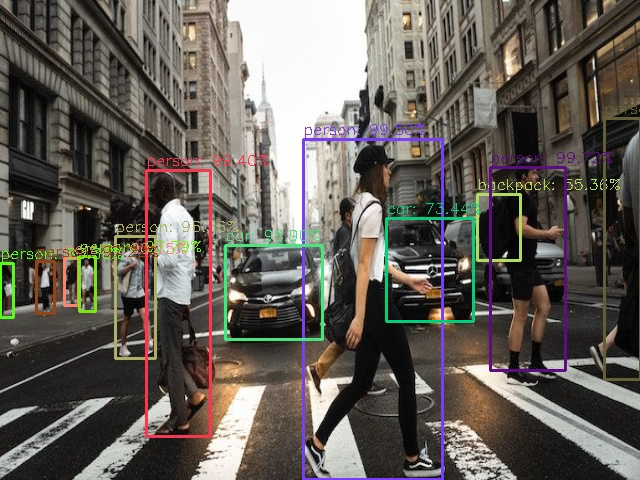




Para o treinamento de um modelo a partir do YOLO, é necessário o preparo do conjunto de dados, fornecendo não apenas as imagens, mas também suas respectivas anotações. Essas anotações consistem em vetores que descrevem a classe do objeto e sua localização na imagem por meio de uma bounding box.

Nas versões modernas do YOLO, cada objeto presente em uma imagem é representado por um vetor de anotação no formato:

<code style="background-color: #fff3cd; color: #856404; padding: 4px 8px; border-radius: 4px;">V = [classe, x_centro, y_centro, altura_bbox, largura_bbox]</code>


![Bounding Box](image-2.png)
	
	
A partir de um dataset estruturado, o YOLO inicia o treinamento do modelo.Durante esse processo, o algoritmo otimiza simultaneamente três aspectos da detecção de objetos:
	- Classificação, responsável por identificar a classe do objeto; 
	- Localização, que ajusta a posição e as dimensões da bounding box;
	- Confiança (confidence score), que estima a probabilidade de a predição corresponder efetivamente à presença de um objeto.
	
Ao final do treinamento, o modelo torna-se capaz de prever a classe, a localização e a confiança associadas a cada objeto presente em uma imagem.

Entretanto, as predições geradas pelo modelo podem conter múltiplas bounding boxes para um mesmo objeto. Para solucionar esse problema, aplica-se uma etapa de pós-processamento denominada Non-Maximum Suppression (NMS). Essa técnica compara as bounding boxes sobrepostas e elimina as predições redundantes, preservando apenas aquela com maior grau de confiança para representar cada objeto detectado.
					[img]
					
					
Neste projeto, foi utilizada a versão 11 do YOLO que, embora não seja a mais recente (2026), apresenta ampla adoção pela comunidade de visão computacional e dispõe de documentação consolidada. Essa escolha proporciona maior estabilidade durante o desenvolvimento e facilita a obtenção de suporte, referências e boas práticas amplamente validadas.


In [1]:
!pip install ultralytics huggingface_hub
from ultralytics import YOLO
from huggingface_hub import snapshot_download
import os, shutil, random, yaml, cv2, glob, json
from IPython.display import Image, display
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


/home/eurico/arquivos/caries-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# https://github.com/Binz-Chan/CVPR2025_OralXrays-9
path = "/home/eurico/temp/OralXrays-9/"

In [3]:
SAIDA = "OralXrays-9/data/"

os.makedirs(f"{SAIDA}/images", exist_ok=True)
os.makedirs(f"{SAIDA}/labels", exist_ok=True)

total = 0
for split in ["train2017", "val2017"]:
    d = json.load(open(f"{path}/annotations/instances_{split}.json"))
    cat = {c["id"]: c["name"] for c in d["categories"]}
    imgs = {i["id"]: i for i in d["images"]}

    porimg = {}
    for a in d["annotations"]:
        if cat.get(a["category_id"]) != "Decay":
            continue
        im = imgs[a["image_id"]]
        x, y, bw, bh = a["bbox"]
        w, h = im["width"], im["height"]
        linha = "0 %.6f %.6f %.6f %.6f" % ((x+bw/2)/w, (y+bh/2)/h, bw/w, bh/h)
        porimg.setdefault(im["file_name"], []).append(linha)

    for nome, linhas in porimg.items():
        shutil.copy(f"{path}/{split}/{nome}", f"{SAIDA}/images/{nome}")
        open(f"{SAIDA}/labels/{os.path.splitext(nome)[0]}.txt", "w").write("\n".join(linhas))

    total += len(porimg)
    print(split, "| imagens:", len(porimg), "| lesoes:", sum(len(v) for v in porimg.values()))

print("total de imagens:", total)

train2017 | imagens: 5181 | lesoes: 9619
val2017 | imagens: 953 | lesoes: 1609
total de imagens: 6134


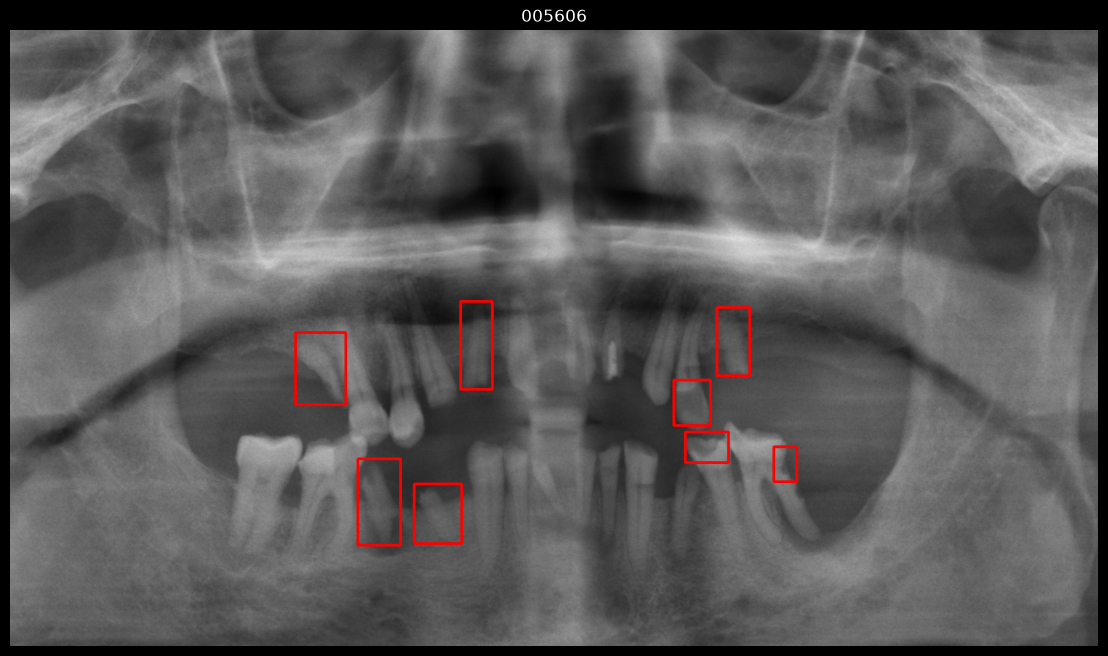

In [4]:
lab = SAIDA + "labels"
img_dir = SAIDA + "images"

arq = sorted(a for a in os.listdir(lab) if open(os.path.join(lab, a)).read().strip())[0]
stem = arq[:-4]
img = cv2.cvtColor(cv2.imread(f"{img_dir}/{stem}.jpg"), cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

for linha in open(f"{lab}/{arq}").read().split("\n"):
    if not linha.strip():
        continue
    _, cx, cy, bw, bh = [float(v) for v in linha.split()]
    p1 = (int((cx-bw/2)*w), int((cy-bh/2)*h))
    p2 = (int((cx+bw/2)*w), int((cy+bh/2)*h))
    cv2.rectangle(img, p1, p2, (255, 0, 0), 4)

plt.figure(figsize=(16, 8)); plt.imshow(img); plt.title(stem); plt.axis("off"); plt.show()

In [5]:
dst = "OralXrays-9/data/"

pares = []
for img in sorted(os.listdir(dst + "/images")):
    rot = os.path.splitext(img)[0] + ".txt"
    if os.path.exists(dst + "/labels/" + rot):
        pares.append((img, rot))

random.Random(42).shuffle(pares)

n = len(pares)
divisoes = {
    "valid": pares[:int(n*0.15)],
    "test":  pares[int(n*0.15):int(n*0.30)],
    "train": pares[int(n*0.30):],
}

for split, itens in divisoes.items():
    os.makedirs(f"{dst}/{split}/images", exist_ok=True)
    os.makedirs(f"{dst}/{split}/labels", exist_ok=True)
    for img, rot in itens:
        shutil.move(f"{dst}/images/{img}", f"{dst}/{split}/images/{img}")
        shutil.move(f"{dst}/labels/{rot}", f"{dst}/{split}/labels/{rot}")
    print(split, len(itens))

shutil.rmtree(dst + "/images", ignore_errors=True)
shutil.rmtree(dst + "/labels", ignore_errors=True)

valid 920
test 920
train 4294


In [6]:
CLASSES = ["carie"]

conteudo = {
    "path": os.path.abspath(dst),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {i: nome for i, nome in enumerate(CLASSES)},
}

destino = os.path.join(dst, "data.yaml")
with open(destino, "w") as f:
    yaml.dump(conteudo, f, sort_keys=False, allow_unicode=True)

print(open(destino).read())

path: /home/eurico/arquivos/caries-detection/notebooks/OralXrays-9/data
train: train/images
val: valid/images
test: test/images
names:
  0: carie



In [7]:
model = YOLO("yolo11s.pt")

model.train(
    data=destino,
    epochs=150,
    imgsz=1024,
    batch=8,
    patience=30,
    seed=42,
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 7806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=OralXrays-9/data/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nm

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fb02152fb00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [8]:
m = model.val(data=destino, split="test")

print("mAP50:     %.4f" % m.box.map50)
print("mAP50-95:  %.4f" % m.box.map)
print("precisao:  %.4f" % m.box.mp)
print("recall:    %.4f" % m.box.mr)
print("F1:        %.4f" % (2*m.box.mp*m.box.mr / (m.box.mp+m.box.mr)))
print("\nvelocidade (ms/imagem):", {k: round(v,1) for k,v in m.speed.items()})

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 7806MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.2±0.1 ms, read: 500.3±146.6 MB/s, size: 521.0 KB)
val: Scanning /home/eurico/arquivos/caries-detection/notebooks/OralXrays-9/data/test/labels... 920 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 920/920 4.3Kit/s 0.2s0.0s
val: New cache created: /home/eurico/arquivos/caries-detection/notebooks/OralXrays-9/data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 58/58 6.2it/s 9.4s0.2s
                   all        920       1728      0.838      0.799      0.862      0.633
Speed: 1.0ms preprocess, 7.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /home/eurico/arquivos/caries-detection/notebooks/runs/detect/val
mAP50:     0.8624
mAP50-95:  0.6333
precisao:  0.8378
recall: 

runs/detect/train

=== results.png


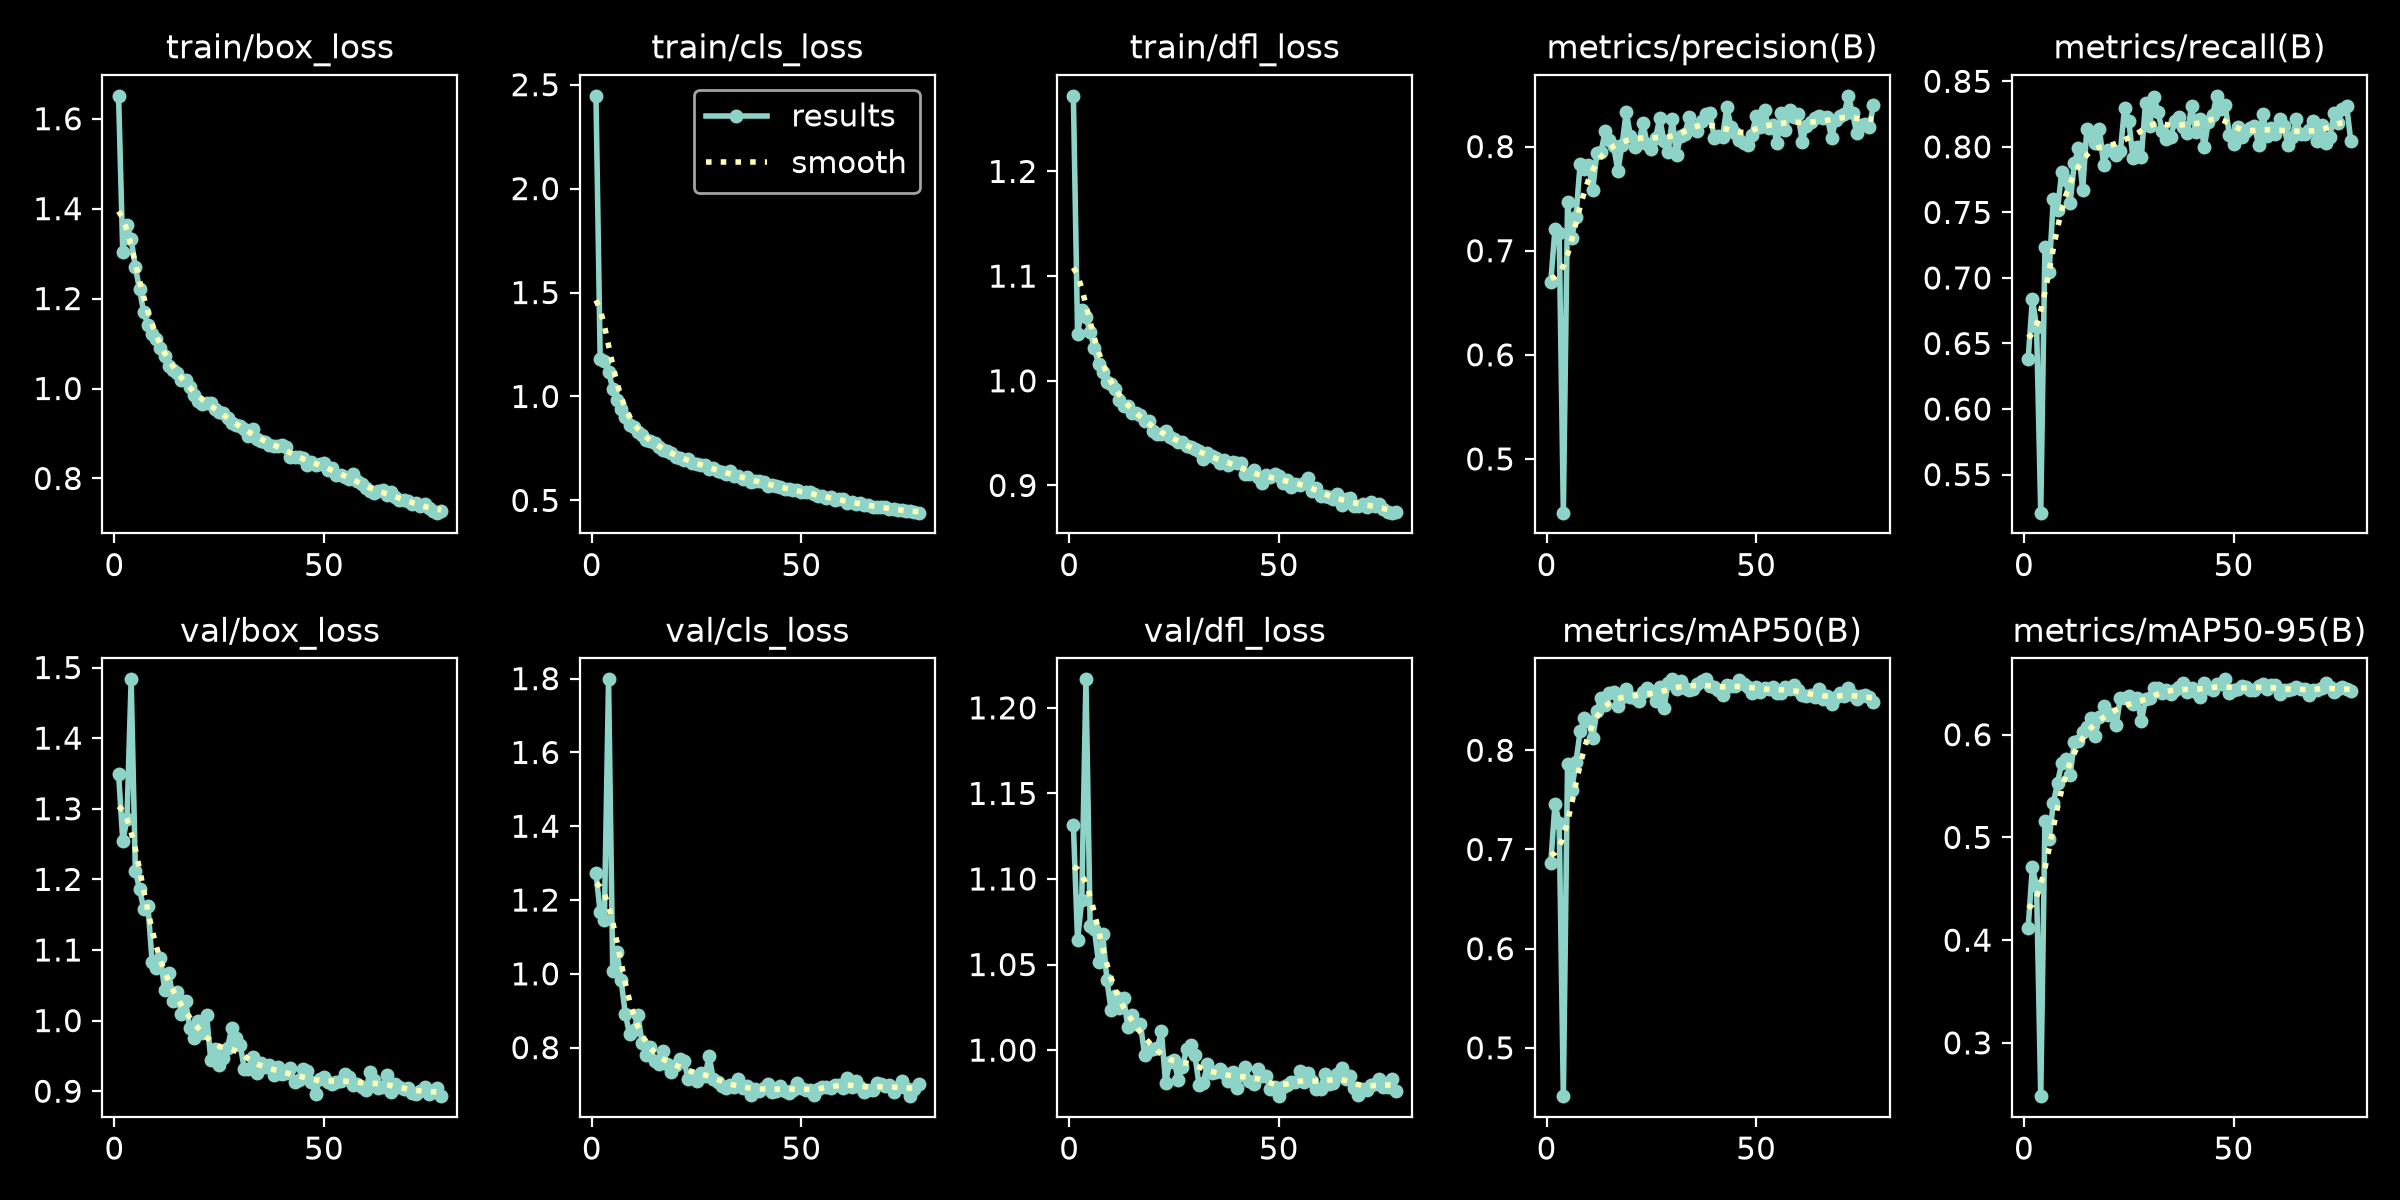


=== confusion_matrix_normalized.png


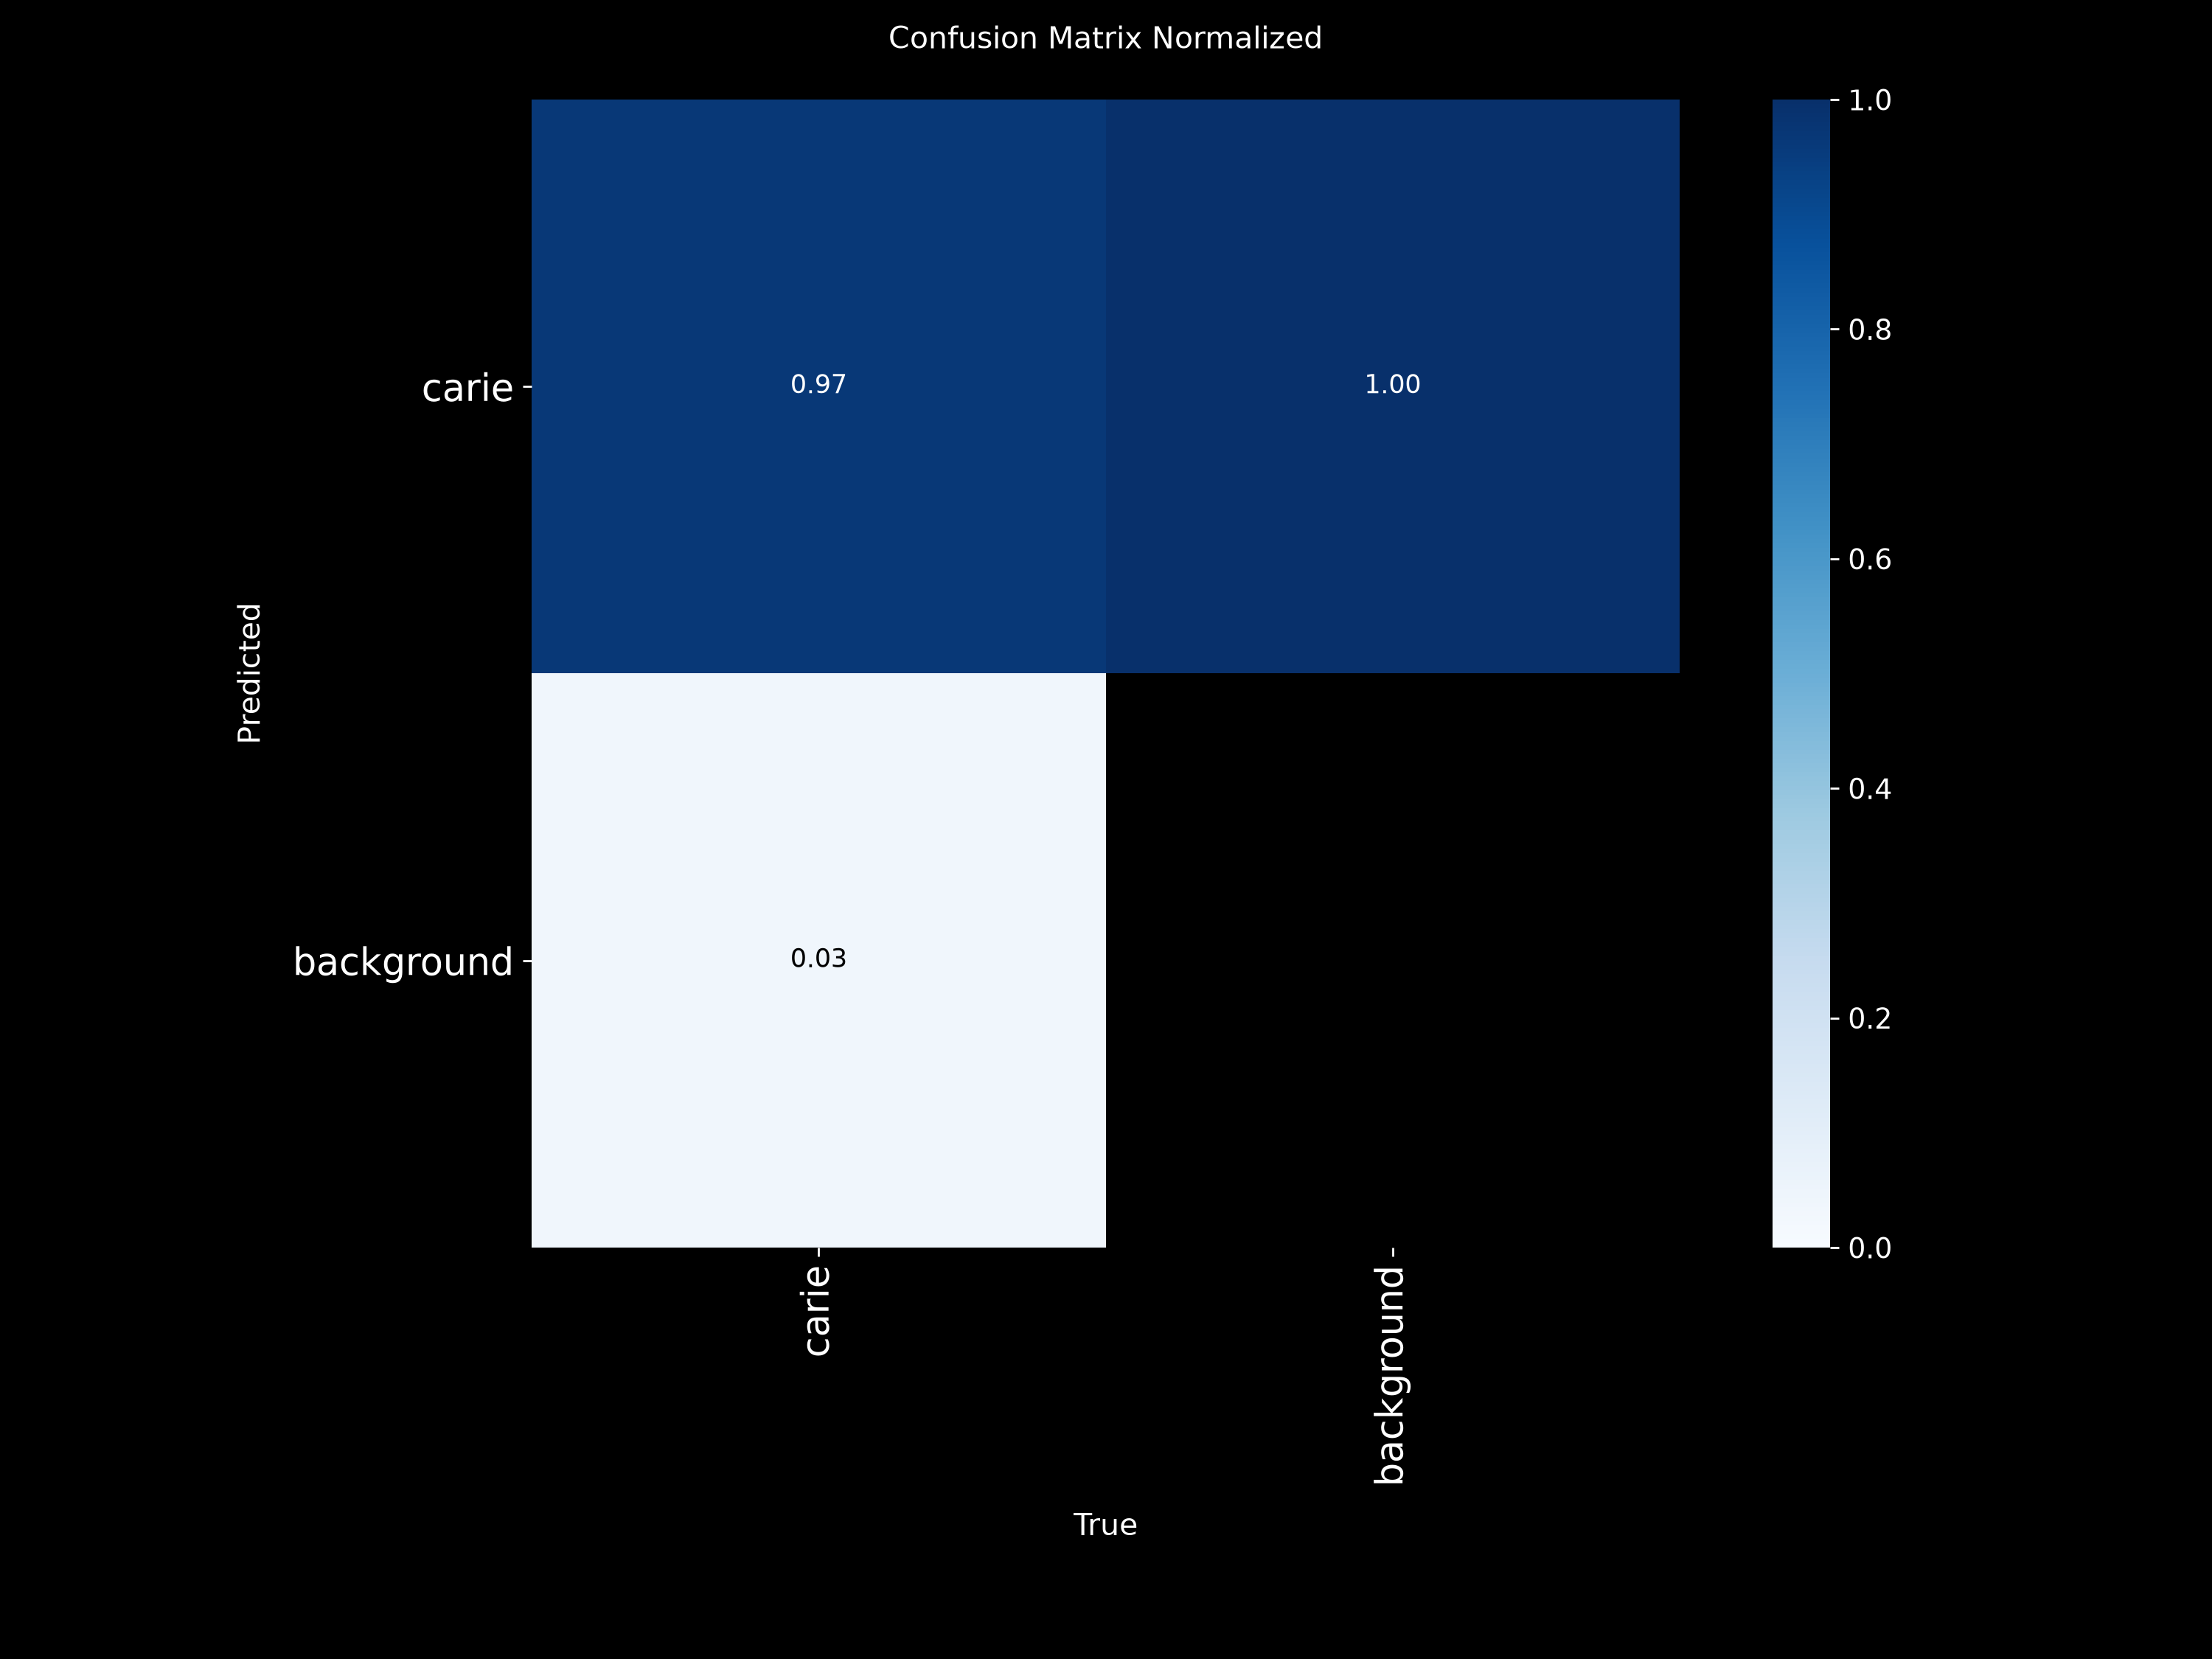


=== labels.jpg


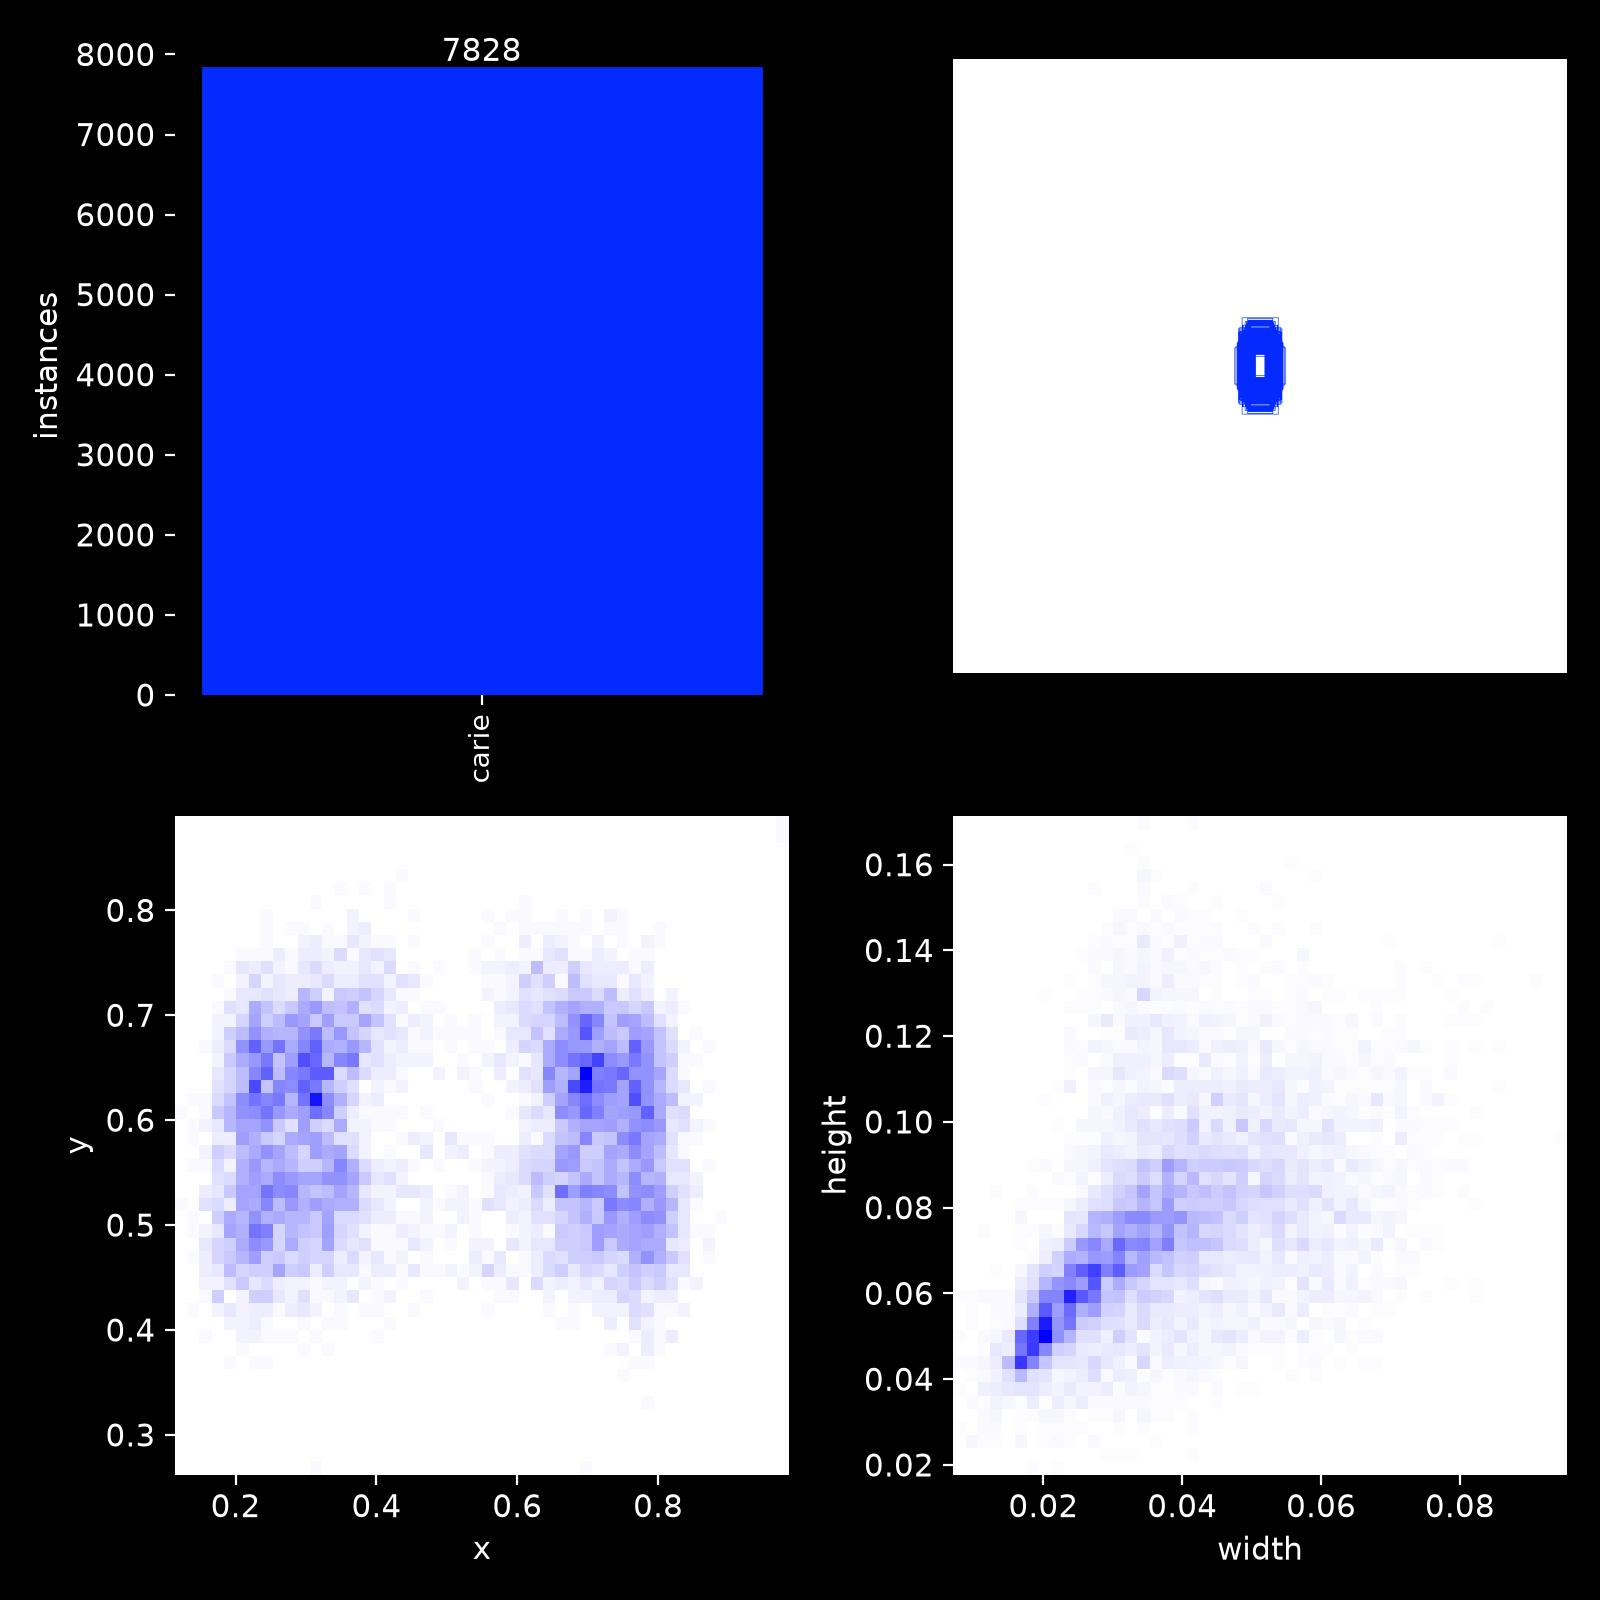


=== val_batch0_labels.jpg


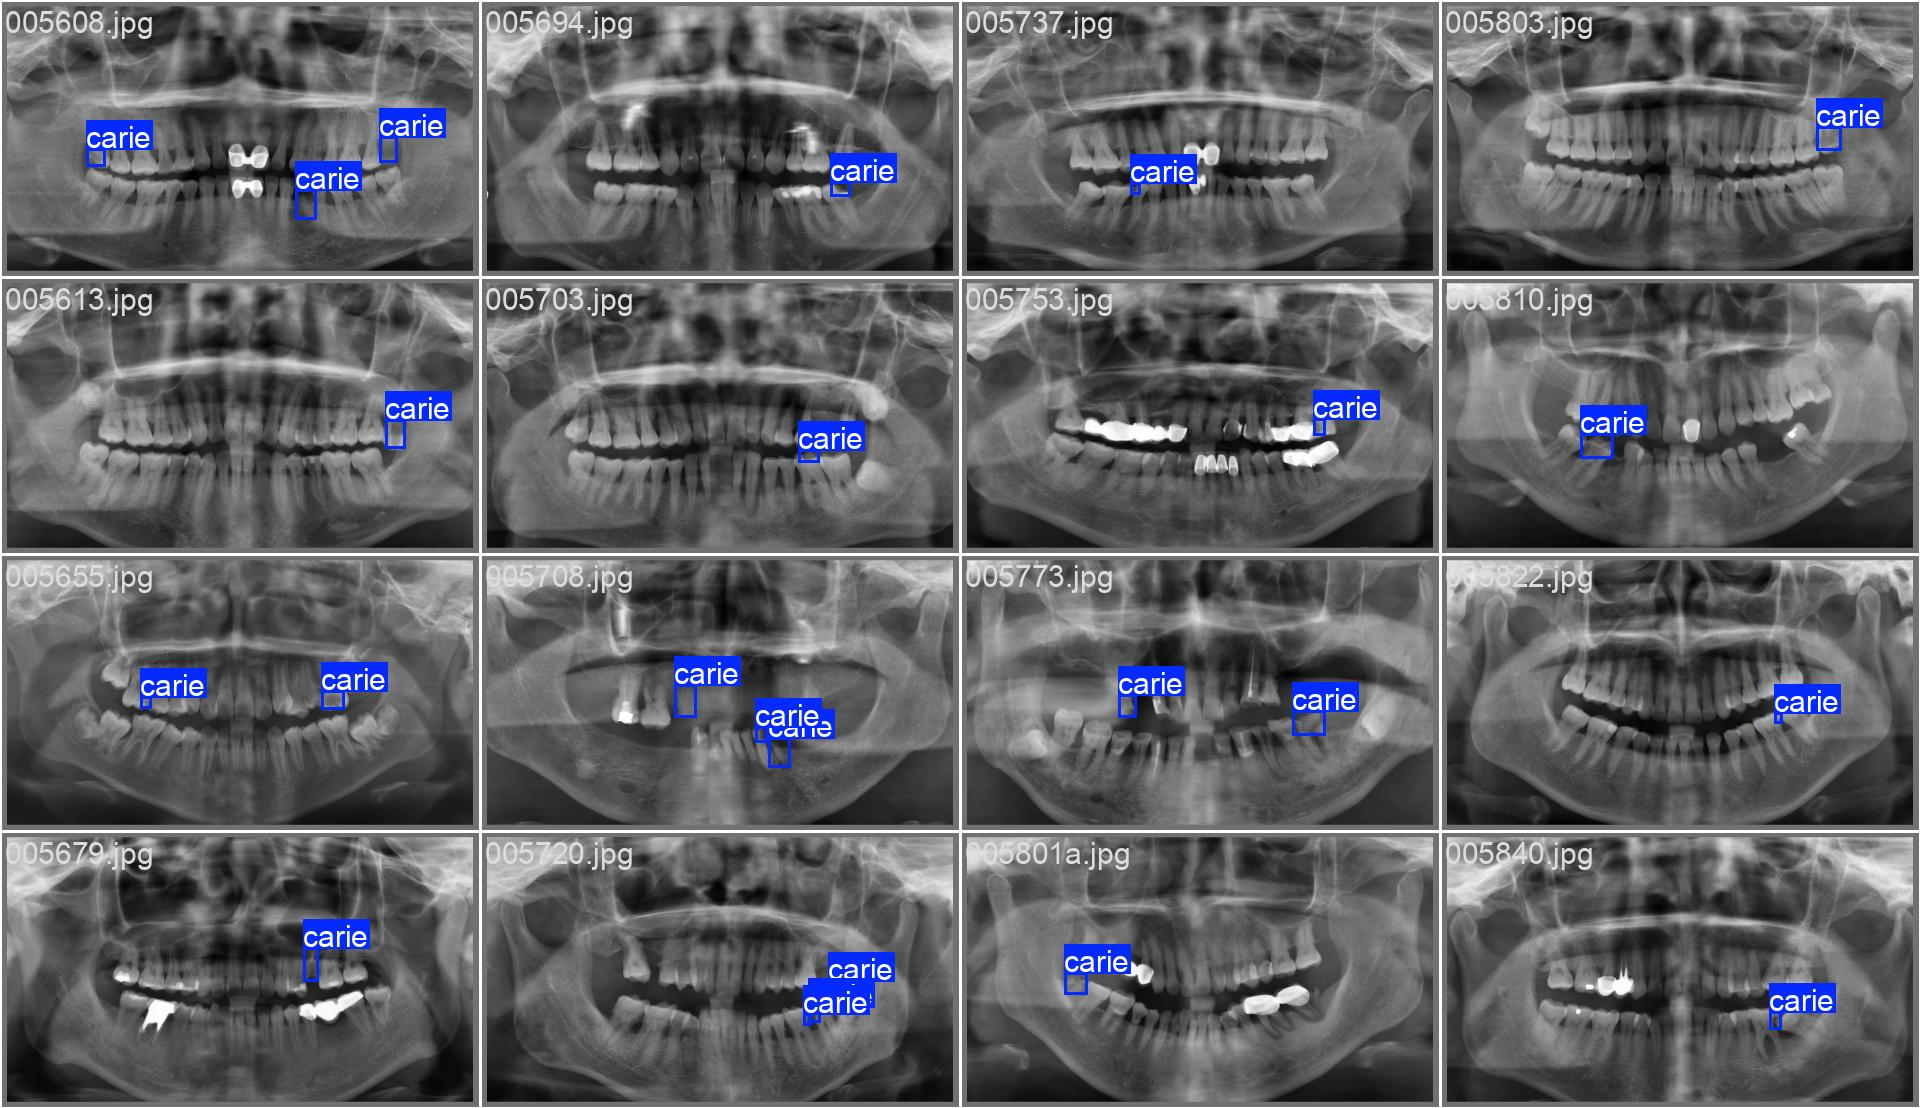


=== val_batch0_pred.jpg


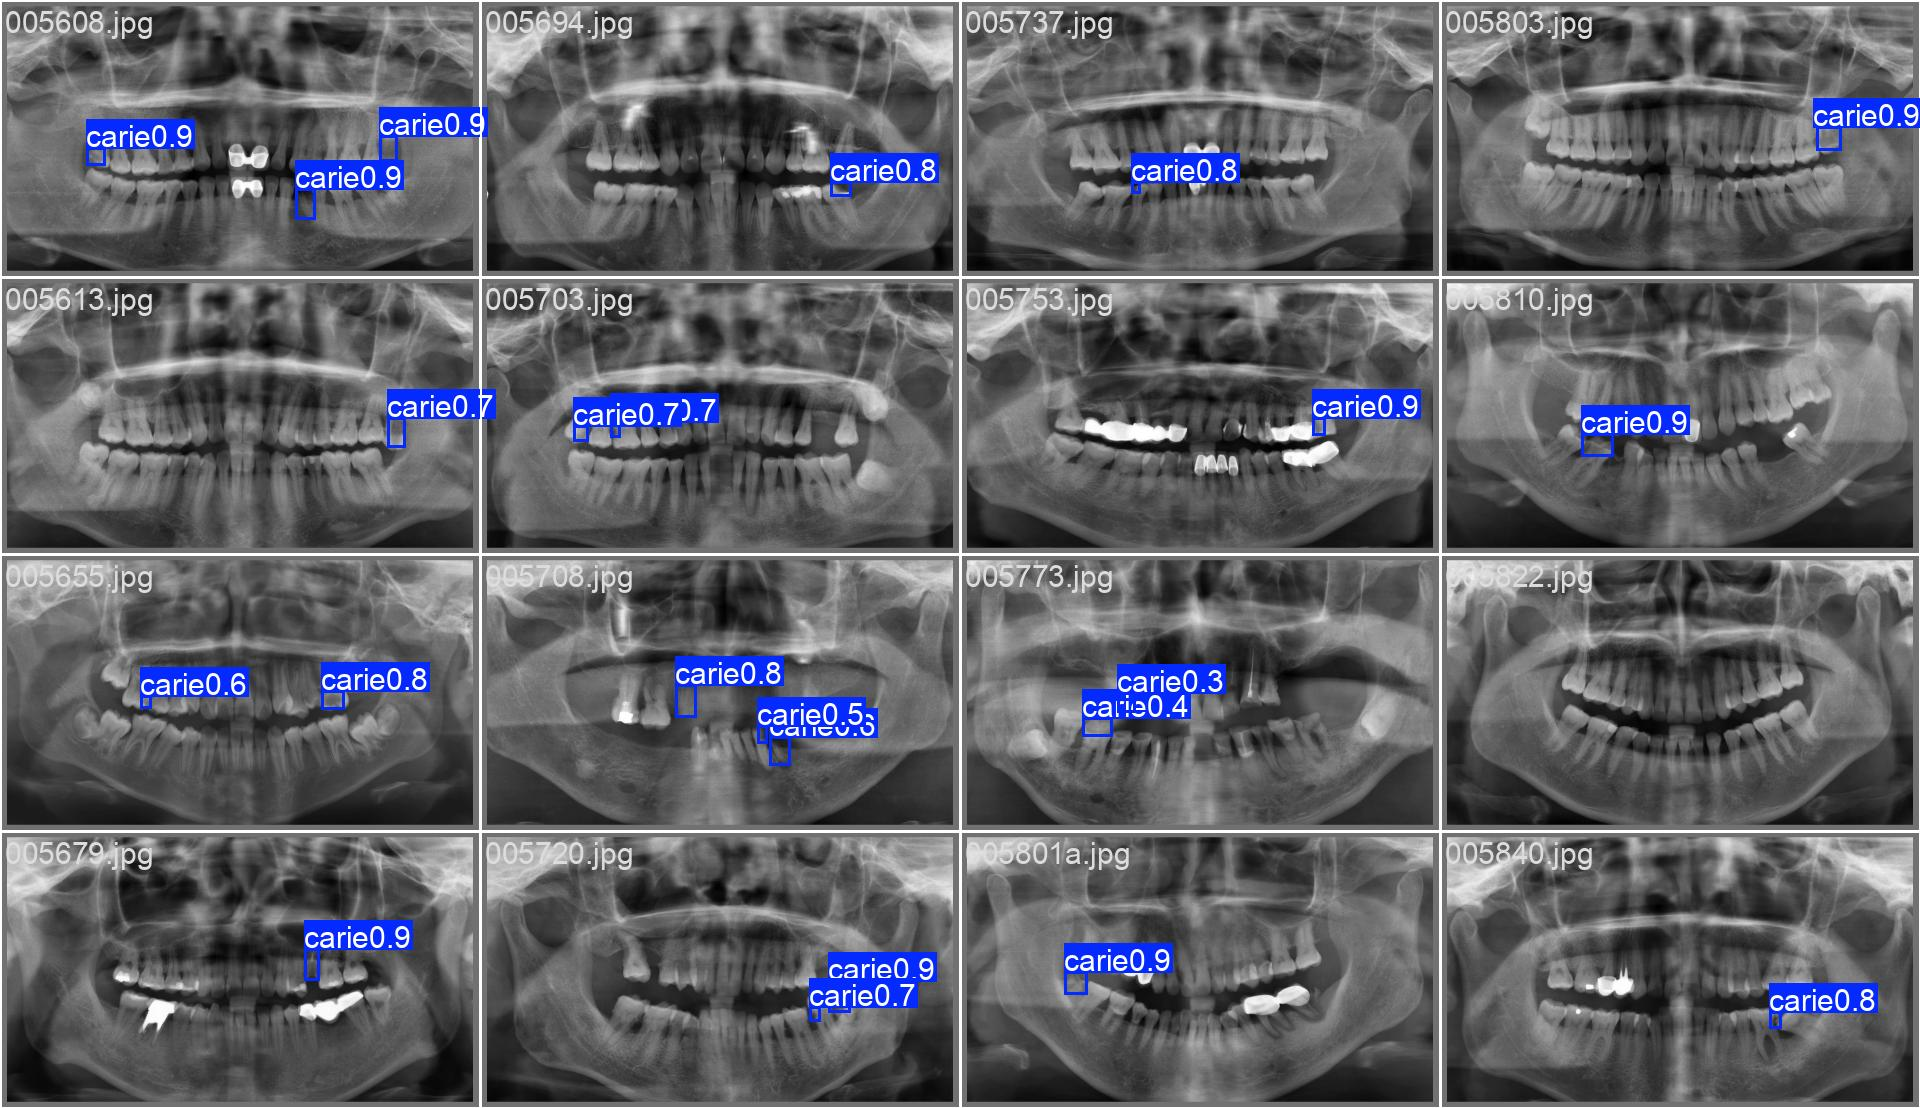

In [9]:
pasta = sorted(glob.glob("runs/detect/train*"))[-1]
print(pasta)

for nome in ["results.png", "PR_curve.png", "F1_curve.png",
             "confusion_matrix_normalized.png", "labels.jpg",
             "val_batch0_labels.jpg", "val_batch0_pred.jpg"]:
    arq = f"{pasta}/{nome}"
    if os.path.exists(arq):
        print("\n===", nome)
        display(Image(filename=arq, width=900))

# Interpretação das Métricas

O modelo apresentou resultados satisfatórios em todas as métricas de avaliação. A __precisão (83,78%)__ indica que a maioria das detecções realizadas corresponde efetivamente aos objetos presentes nas imagens, enquanto o __recall (79,86%)__ demonstra boa capacidade de localizar os objetos existentes no conjunto de validação.

O __F1-score (81,77%)__ evidencia um equilíbrio entre precisão e recall, indicando consistência no desempenho do modelo. Já o __mAP@50 (86,24%)__ confirma elevada qualidade na detecção dos objetos, enquanto o __mAP@50-95 (63,33%)__ mostra que o modelo mantém desempenho satisfatório mesmo sob critérios de avaliação mais rigorosos.

De forma geral, os resultados obtidos validam a eficácia do treinamento realizado, demonstrando que o modelo é capaz de detectar os objetos de interesse com boa precisão e confiabilidade.


# Conclusão

Os resultados obtidos demonstram que os objetivos deste projeto foram alcançados. O modelo treinado apresentou desempenho satisfatório na detecção de cáries em radiografias panorâmicas, evidenciando sua capacidade de identificar e localizar regiões com indícios de lesões.

Dessa forma, conclui-se que a utilização do YOLO para o treinamento por fine-tuning sobre o conjunto de dados, constitui uma abordagem eficaz para a tarefa proposta. 

O modelo desenvolvido tem potencial para atuar como uma ferramenta de apoio ao diagnóstico odontológico, auxiliando profissionais na identificação de possíveis lesões por meio da marcação automática de suas localizações, sem substituir a avaliação clínica realizada pelo dentista.